In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
df.shape

(1407328, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [6]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)

df["date_only"] = df["date"].dt.date
df["hour"] = df["date"].dt.hour
df["day_name"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.to_period("M").astype(str)

df.head()

,Unnamed: 0,headline,url,publisher,date,stock,date_only,hour,day_name,month
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,2020-06-05,14.0,Friday,2020-06
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,2020-06-03,14.0,Wednesday,2020-06
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,2020-05-26,8.0,Tuesday,2020-05
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,2020-05-22,16.0,Friday,2020-05
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,2020-05-22,15.0,Friday,2020-05


In [9]:
df["headline_length"] = df["headline"].astype(str).str.len()
df["word_count"] = df["headline"].astype(str).str.split().str.len()

df[["headline_length", "word_count"]].describe()

,headline_length,word_count
count,1.407328e+06,1.407328e+06
mean,7.312051e+01,1.141671e+01
std,4.073531e+01,6.352997e+00
min,3.000000e+00,1.000000e+00
25%,4.700000e+01,7.000000e+00
50%,6.400000e+01,1.000000e+01
75%,8.700000e+01,1.300000e+01
max,5.120000e+02,7.700000e+01


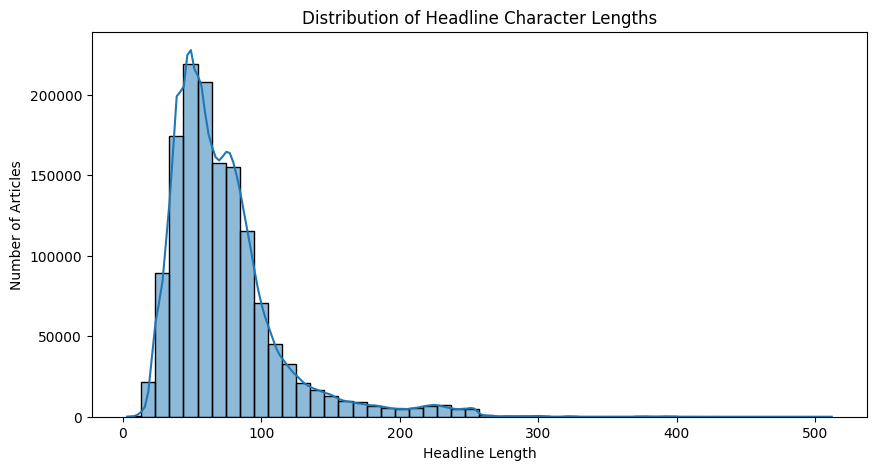

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df["headline_length"], bins=50, kde=True)
plt.title("Distribution of Headline Character Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Number of Articles")
plt.show()

In [11]:
top_publishers = df["publisher"].value_counts().head(15)
top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64

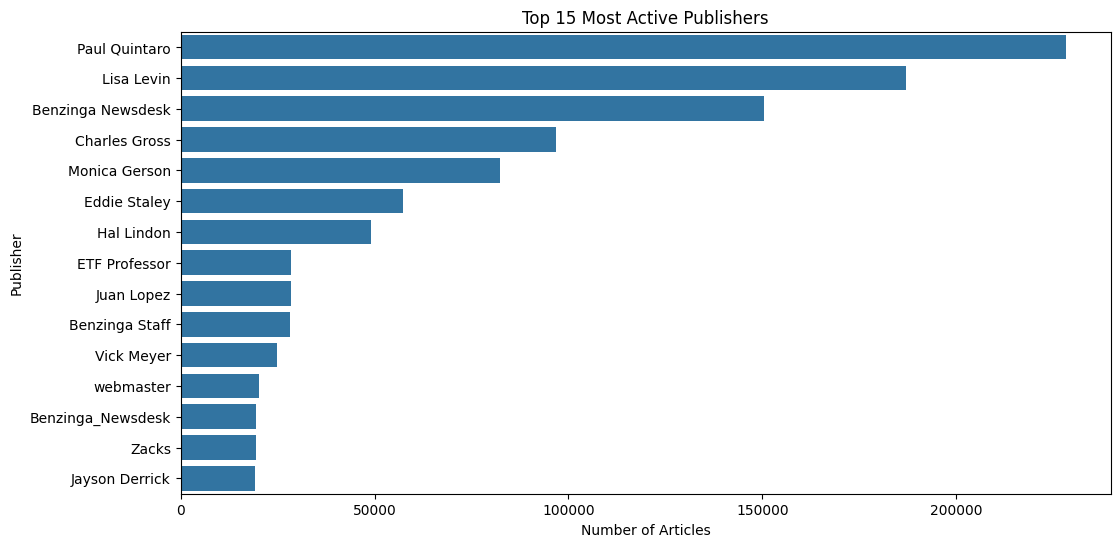

In [12]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top 15 Most Active Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")
plt.show()

In [13]:
daily_news = df.groupby("date_only").size().reset_index(name="article_count")
daily_news.head()

,date_only,article_count
0,2011-04-28,3
1,2011-04-29,2
2,2011-04-30,1
3,2011-05-01,1
4,2011-05-02,9


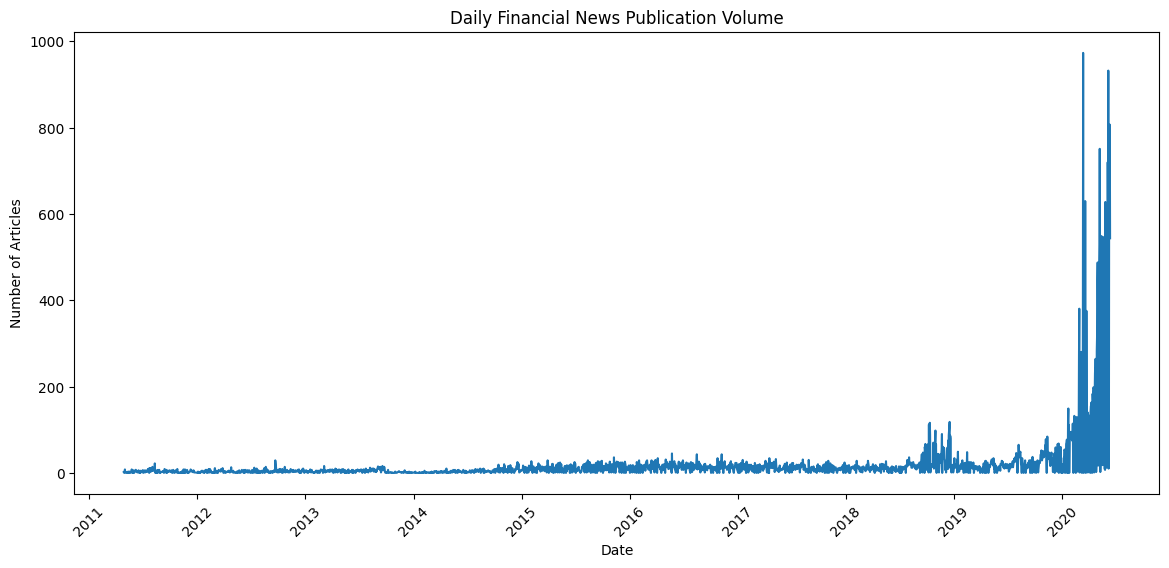

In [14]:
plt.figure(figsize=(14,6))
plt.plot(daily_news["date_only"], daily_news["article_count"])
plt.title("Daily Financial News Publication Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [15]:
hourly_news = df["hour"].value_counts().sort_index()
hourly_news

hour
0.0      131
1.0       82
2.0       48
3.0       27
4.0       67
5.0       14
6.0       57
7.0       93
8.0     1469
9.0     1829
10.0    2476
11.0    5033
12.0    5527
13.0    5965
14.0    7669
15.0    5701
16.0    5732
17.0    2710
18.0    2075
19.0    1612
20.0    3939
21.0    2800
22.0     704
23.0     227
Name: count, dtype: int64

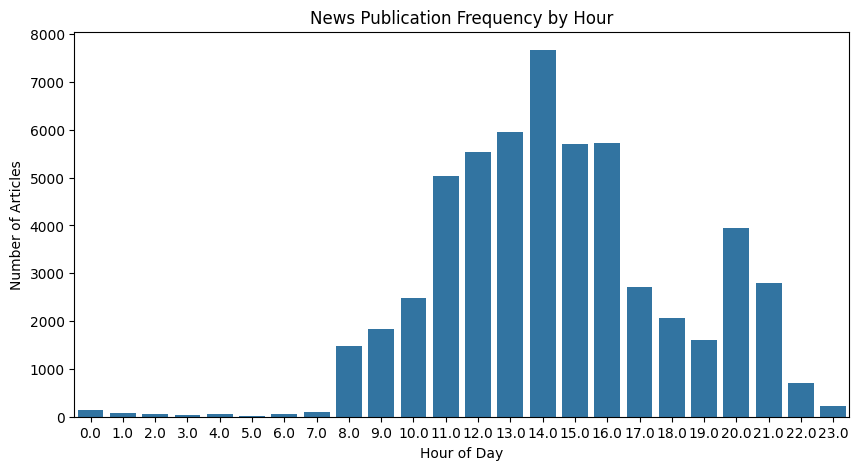

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x=hourly_news.index, y=hourly_news.values)
plt.title("News Publication Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.show()

In [17]:
headlines = df["headline"].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(headlines)

keywords = pd.DataFrame({
    "keyword": vectorizer.get_feature_names_out(),
    "frequency": X.toarray().sum(axis=0)
}).sort_values(by="frequency", ascending=False)

keywords.head(20)

,keyword,frequency
28,vs,162099
23,stocks,161776
10,est,140604
9,eps,128897
13,market,120558
22,shares,114313
20,reports,108710
26,update,91723
8,earnings,87399
21,sales,79645


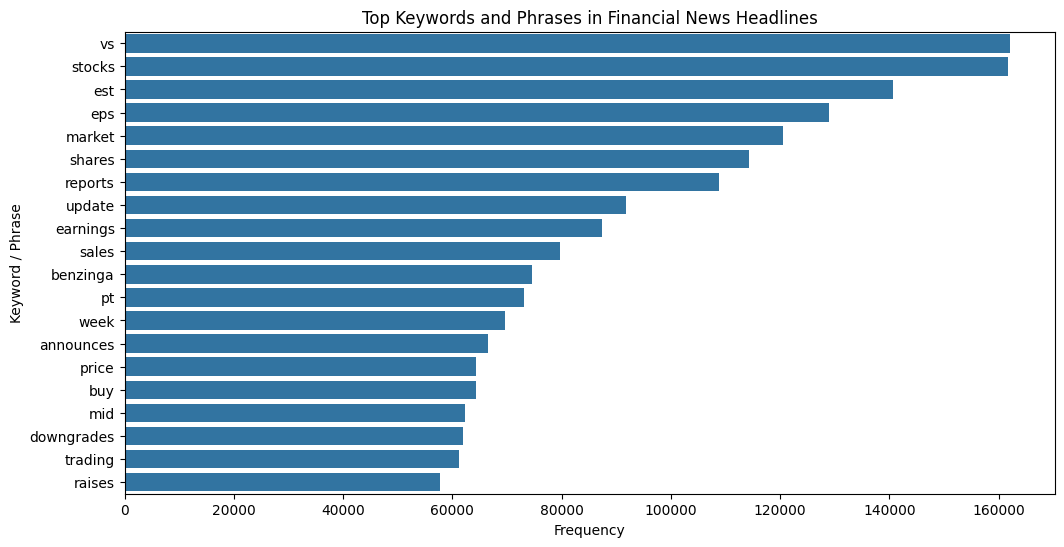

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(data=keywords.head(20), x="frequency", y="keyword")
plt.title("Top Keywords and Phrases in Financial News Headlines")
plt.xlabel("Frequency")
plt.ylabel("Keyword / Phrase")
plt.show()

In [19]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(headlines)

tfidf_scores = pd.DataFrame({
    "term": tfidf.get_feature_names_out(),
    "score": tfidf_matrix.sum(axis=0).A1
}).sort_values(by="score", ascending=False)

tfidf_scores.head(20)

,term,score
23,stocks,105575.286232
13,market,79449.023620
8,earnings,74196.078414
22,shares,71977.750223
28,vs,64988.818994
20,reports,63067.365973
9,eps,60432.531200
26,update,59904.198072
4,benzinga,57644.663986
10,est,53292.271269


In [20]:
def extract_domain(publisher):
    publisher = str(publisher)
    if "@" in publisher:
        return publisher.split("@")[-1]
    return "non-email publisher"

df["publisher_domain"] = df["publisher"].apply(extract_domain)

df["publisher_domain"].value_counts().head(15)

publisher_domain
non-email publisher       1399240
benzinga.com                 7937
gmail.com                     139
andyswan.com                    5
investdiva.com                  2
tothetick.com                   2
eosdetroit.io                   1
forextraininggroup.com          1
stockmetrix.net                 1
Name: count, dtype: int64

In [21]:
top_stocks = df["stock"].value_counts().head(15)
top_stocks

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
Name: count, dtype: int64

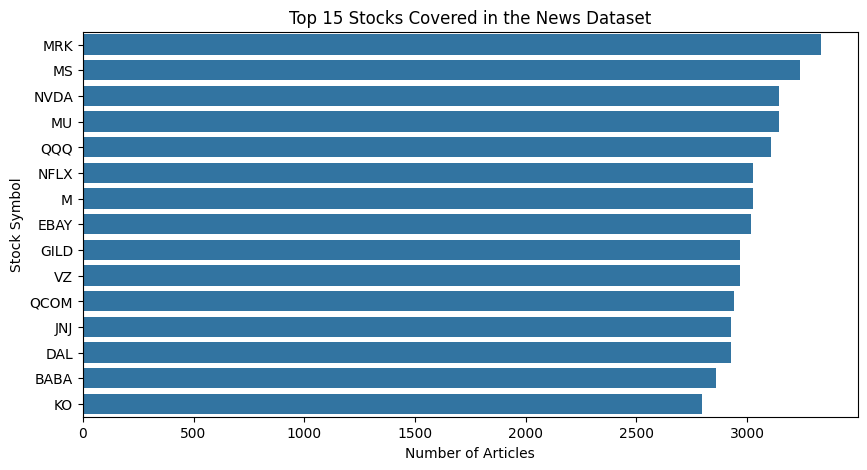

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_stocks.values, y=top_stocks.index)
plt.title("Top 15 Stocks Covered in the News Dataset")
plt.xlabel("Number of Articles")
plt.ylabel("Stock Symbol")
plt.show()

### Key Insights from Task 1 EDA

1. The headline length distribution shows how concise or detailed financial news headlines are. Most headlines are short, which makes them suitable for NLP-based sentiment analysis.

2. Publisher analysis reveals which sources contribute the largest amount of financial news. Highly active publishers may strongly influence the overall sentiment distribution in the dataset.

3. Publication volume changes over time, with visible spikes on certain dates. These spikes may correspond to earnings announcements, analyst rating changes, market volatility, or major company-specific events.

4. Keyword and phrase analysis shows recurring financial themes such as earnings, price targets, stock movement, analyst ratings, FDA approvals, and market updates.

5. Publishing time analysis helps identify when financial news is usually released, which is important because articles published before or during market hours may affect same-day price movement differently from after-hours articles.